In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

import procedures as pc

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import json
import dynamax
#%matplotlib ipympl 

import statsmodels.api as sm

from sklearn.preprocessing import power_transform


In [2]:
PCAData = pd.read_csv("data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

PCAHeaders = [str(i) for i in range(0,8)]

pumpList = PCAData["Well Run"].unique()


/tmp/ipykernel_108149/2924506897.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [3]:
PCAData[["Transformed Square","VibNormX","VibNormY"]] = 0.0

for pump in pumpList:
    pumpData = PCAData.loc[PCAData["Well Run"] == pump]
    PCAData.loc[pumpData.index,"Transformed Square"] = li.BoxCoxProccess(pumpData,"Square")
    PCAData.loc[pumpData.index,"VibNormX"] = li.BoxCoxProccess(pumpData,"ESP Vibration X")
    PCAData.loc[pumpData.index,"VibNormY"] = li.BoxCoxProccess(pumpData,"ESP Vibration Y")

modelData = PCAData.loc[PCAData["Well_down"]==0].copy() #dados de operação apenas, dados desligados não são considerados


with open('list_names.txt', 'r') as file:
    pumpList = np.array(json.load(file))

#PCAData.set_index("time",inplace=True)

In [4]:
# transformedData = pd.DataFrame(columns=list(PCAData),index=range(len(PCAData)))
# notOpHeader = list(set(list(PCAData))-set(PCAHeaders))

# transformedData[notOpHeader] = PCAData[notOpHeader]


# for pump in pumpList:
#     data = PCAData.loc[PCAData["Well Run"]==pump]
#     newData = PowerTransformer().fit_transform(data[PCAHeaders])
#     transformedData.loc[PCAData["Well Run"]==pump,PCAHeaders] = newData.copy()

In [5]:
#PCAData["Transformed Square"].hist(bins=20)
#PCAData["Square"].hist()

In [6]:
mainSeed = 19971215

np.random.seed(mainSeed)
proportion = 0.75
modelData = modelData.sort_values(["Well Run","time"])
X_train,trainLength, X_test, testLength = li.Splitter(pumpList,proportion,modelData)

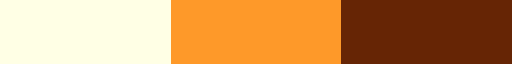

In [7]:
# Exemplo de estados ao longo do tempo
n = 2
states = range(0,n+1)

# Gerando cores automáticas com base no número de estados
num_states = len(np.unique(states))
cmap = plt.get_cmap('YlOrBr', num_states)  # Escolhe um colormap com num_states cores

cmap

In [8]:
totalLength = np.concatenate([trainLength,testLength])

modelData = pd.concat([X_train,X_test])

In [9]:
model = hmm.GMMHMM(n_components=n,n_mix=2,covariance_type="full",random_state=mainSeed)
#model = hmm.GaussianHMM(n_components=n,random_state=mainSeed)
model.fit(X_train[PCAHeaders],trainLength)#+['Water Cut @ 20degC - 1 atm','Choke Opening']])
modelData["State"] = model.predict(modelData[PCAHeaders],totalLength)+1;

np.log(model.aic(X_train[PCAHeaders]))

16.13457645834229

In [10]:
#li.QQPlots(PCAData[["ESP Vibration Y","ESP Vibration X"]],["ESP Vibration Y","ESP Vibration X"])

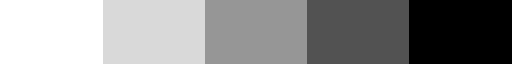

In [11]:
# Exemplo de estados ao longo do tempo
n_1 = 4
states_1 = range(0,n_1+1)
# Gerando cores automáticas com base no número de estados
cmap1 = plt.get_cmap('Greys', n_1+1)  # Escolhe um colormap com num_states cores

cmap1

In [12]:
modelSq = hmm.GaussianHMM(n_components=n_1,random_state=mainSeed)
modelSq.fit(X_train["Transformed Square"].to_numpy().reshape(-1,1),trainLength)#+['Water Cut @ 20degC - 1 atm','Choke Opening']])
modelData["State 2"] = modelSq.predict(modelData["Transformed Square"].to_numpy().reshape(-1,1),totalLength)+1;

np.log(modelSq.aic(X_train["Transformed Square"].to_numpy().reshape(-1,1)))


13.502745334474644

In [13]:
PCAData["State"] = 0
PCAData["State Gaussian"] = 0
# PCAData["Square State"] = 0
#PCAData.loc[PCAData["Well_down"]==0] =  #copy()?

PCAData.loc[modelData["State"].index,"State"] = modelData["State"]
PCAData.loc[modelData["State 2"].index,"State Gaussian"] = modelData["State 2"]
# PCAData.loc[modelData["Square State"].index,"Square State"] = modelData["Square State"]

In [14]:
# modelData = PCAData.loc[PCAData["Well_down"]==0].copy() #dados de operação apenas, dados desligados não são considerados
# modelData = modelData.sort_values(["Well Run","time"])
# X_train,trainLength, X_test, testLength = li.Splitter(pumpList,proportion,modelData)

# modelCat = hmm.PoissonHMM(n_components=3,random_state=mainSeed)
# modelCat.fit(X_train["State"].to_numpy().reshape(-1,1),trainLength)
# modelData["Categorical State"] = modelCat.predict(modelData[["State"]].to_numpy(),totalLength)+1;


# np.log(modelCat.aic(modelData[["State"]].to_numpy()))

# PCAData["Categorical State"] = 0
# # PCAData["Square State"] = 0
# #PCAData.loc[PCAData["Well_down"]==0] =  #copy()?

# PCAData.loc[modelData["Categorical State"].index,"Categorical State"] = modelData["Categorical State"]
# # PCAData.loc[modelData["Square State"].index,"Square State"] = modelData["Square State"]

In [15]:
print(model.get_stationary_distribution())
print(modelSq.get_stationary_distribution())

[0.50323194 0.49676806]
[0.2248267  0.37168915 0.10698036 0.29650379]


In [16]:
stateOrder = np.argsort(modelSq.get_stationary_distribution())+1
stateOrder = np.insert(np.flip(stateOrder),0,0)

conversion = dict(zip(stateOrder,range(0,n_1+1)))
PCAData["State Gaussian"] = PCAData["State Gaussian"].map(conversion)

(<Figure size 6000x2000 with 2 Axes>,
 array([<Axes: xlabel='time'>, <Axes: xlabel='time'>], dtype=object))

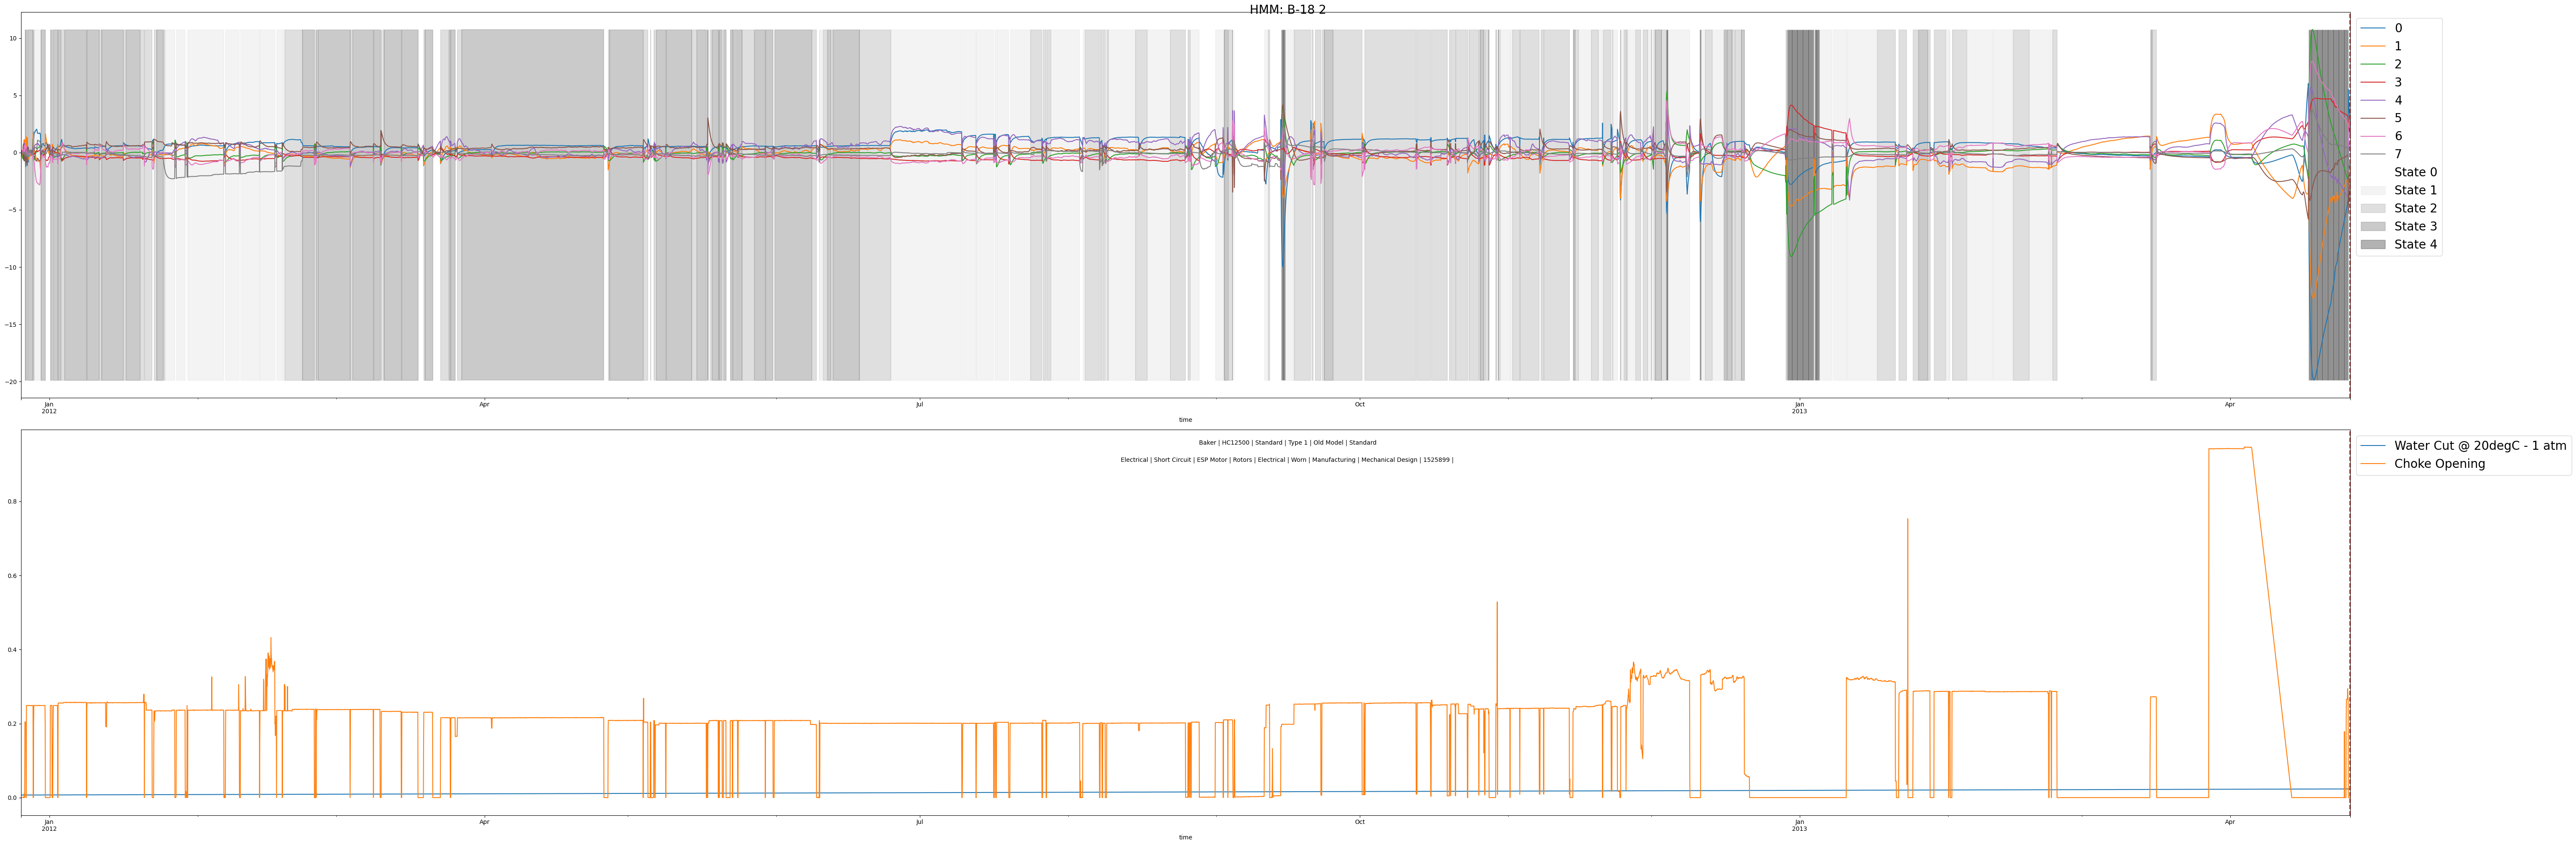

In [17]:
pump = pumpList[0]
pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)


In [ ]:
for pump in pumpList:
   
    pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

    fig, axs = li.HMMPicture(pumpData,pump,PCAHeaders,cmap1,n_1)

    fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
    plt.close()

In [ ]:
# import dynamax.hidden_markov_model as hmm


# model = hmm.LinearAutoregressiveHMM(num_states=4,emission_dim=5)
# model.fit_em()


#  pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()

#     pumpData["time"] = pd.to_datetime(pumpData["time"])
#     pumpData.set_index("time",inplace=True)

#     pumpData = pumpData.asfreq('h',fill_value=0)

#     pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])

#     fig, ax = plt.subplots(4,1, figsize=(50,15))

#     pumpData[PCAHeaders].plot(ax=ax[0])


#     # Preenchendo as áreas de acordo com os estados
#     for state in np.unique(states):
#         color = cmap(state)  # Pega uma cor automática para cada estado
#         ax[0].fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
#                         color=color, alpha=0.3, label=f"Estado {state}")
        
#     ax[0].legend(loc='upper left',bbox_to_anchor=(1, 1))


#     # for shut in pumpData["Shutdown"].loc[pumpData["Shutdown"] == True].index:
#     #       ax[0].axvline(x=shut, color='black', linestyle='-', linewidth=0.5)





#     norm = mcolors.Normalize(vmin=-6, vmax=6)

#     its = ax[3].pcolor(pumpData[PCAHeaders].T,cmap='hsv', norm=norm)
#     ax[3].grid(axis="y",linewidth=1,color="black")
#     ax[3].tick_params(axis='both', which='both', length=0)  # Remove ticks
#     ax[3].set_xticklabels([])  # Remove labels no eixo x


#     ax[3].set_title(str(pumpData["Pump Info"].iloc[0])+" "+str(pumpData["Failure Info"].iloc[0]))




#     if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
#             failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
#             ax[3].axvline(x=failureX, color='red', linestyle='--', linewidth=1)


#     fig.colorbar(its,ax=ax[3],orientation='horizontal',shrink=0.5)


#     fig.suptitle("HMM e Imshow: " + pump);
#     plt.tight_layout()
#     fig.savefig("imagens/heatmap2/heatmap-"+pump+".png")
#     plt.close()

In [ ]:
pump = pumpList[0]
pumpData = PCAData.loc[PCAData["Well Run"]==pump].copy()
plt.rcParams['font.size'] = 15.0
pumpData["time"] = pd.to_datetime(pumpData["time"])
pumpData.set_index("time",inplace=True)

pumpData = pumpData.asfreq('h',fill_value=0)

pumpData["Shutdown"] = pumpData["Well_down"] != pumpData["Well_down"].shift(-1).fillna(pumpData["Well_down"].iloc[-1])


fig, ax = plt.subplots(1,1, figsize=(20,10))

pumpData[PCAHeaders].plot(ax=ax)


# Preenchendo as áreas de a
# cordo com os estados
for state in np.unique(states):
        color = cmap(state)  # Pega uma cor automática para cada estado
        ax.fill_between(pumpData.index, np.min(pumpData[PCAHeaders]), np.max(pumpData[PCAHeaders]), where=(pumpData["State"] == state), 
                        color=color, alpha=0.3, label=f"State {state}")

        ax.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=15)



if pumpData.loc[pumpData["Failure"]==True].shape[0] != 0:
        #failureX = pumpData.index.get_loc(pumpData.loc[pumpData["Failure"]==True].index[0])
        ax.axvline(x=pumpData.loc[pumpData["Failure"]==True].index[0], color='red', linestyle='--', linewidth=5)


fig.suptitle("HMM: " + pump,fontsize=20);
fig.savefig("imagens/relatorio/hmm")